In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score

from scipy.stats import loguniform
from time import time

df = pd.read_csv("chlor.csv")
df.head()

,Chl_a,Phy,NO2,NO3,NH4,PO4,Site,Bay,Depth
0,6.66,0.74,0.21830,0.522735,31.784807,15.317651,XVI,West Bay,1.097
1,6.45,0.78,0.21830,0.522735,31.784807,15.317651,XVI,West Bay,1.098
2,6.27,0.77,0.21830,0.522735,31.784807,15.317651,XVI,West Bay,1.098
3,6.13,0.58,0.21495,0.527931,30.446107,14.834307,XVI,West Bay,2.004
4,6.10,0.57,0.21495,0.527931,30.446107,14.834307,XVI,West Bay,2.004


In [2]:
print(f'No. of rows: {len(df)}')

df.dropna(inplace=True)
df.drop(['Phy'], axis=1, inplace=True)

print(f'After removing missing values: {len(df)}')

No. of rows: 255
After removing missing values: 109


In [3]:
# Get the [NO2-], [NO3-], [NH4+], and [PO43-] as "X", then Chl-a as "y"
X, y = df.iloc[:,1:5].to_numpy(), df['Chl_a'].to_numpy()

# Create a new X with TN and TP as the columns
X = np.hstack((X[:,:2].sum(axis=1, keepdims=True), X[:,-1].reshape(-1,1)))
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.4,random_state=0,stratify=df['Site'])


In [24]:
pipeline = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("regress", MLPRegressor(max_iter=5000, random_state=0))
    ]
)

model_params = {"regress__alpha": loguniform(1e-4,1),
                "regress__solver": ["adam","sgd"],
                "regress__hidden_layer_sizes":
                    [(i, j, k) for i in range(10, 50) for j in range(8, i+1) for k in range(8, j+1)],
                "regress__activation":["relu","tanh","identity"]}

n_iter = 100
random_search = RandomizedSearchCV(pipeline,
                                   param_distributions=model_params,
                                   n_iter=n_iter,cv=5,verbose=2)

start = time()
random_search.fit(X_train, y_train)
print("RandomizedSearchCV took %.2f seconds for %d candidates parameter settings."
        % ((time() - start), n_iter))

print("\nBest Parameters:")
print(random_search.best_params_)

best_model = random_search.best_estimator_

print("\nBest Model:")
print(best_model)

Fitting 5 folds for each of 100 candidates, totalling 500 fits
[CV] END regress__activation=relu, regress__alpha=0.012796404257679516, regress__hidden_layer_sizes=(48, 35, 28), regress__solver=adam; total time=   0.2s
[CV] END regress__activation=relu, regress__alpha=0.012796404257679516, regress__hidden_layer_sizes=(48, 35, 28), regress__solver=adam; total time=   0.3s
[CV] END regress__activation=relu, regress__alpha=0.012796404257679516, regress__hidden_layer_sizes=(48, 35, 28), regress__solver=adam; total time=   0.2s
[CV] END regress__activation=relu, regress__alpha=0.012796404257679516, regress__hidden_layer_sizes=(48, 35, 28), regress__solver=adam; total time=   0.2s
[CV] END regress__activation=relu, regress__alpha=0.012796404257679516, regress__hidden_layer_sizes=(48, 35, 28), regress__solver=adam; total time=   0.4s
[CV] END regress__activation=identity, regress__alpha=0.002261642779138497, regress__hidden_layer_sizes=(37, 15, 9), regress__solver=adam; total time=   0.0s
[CV]

[CV] END regress__activation=relu, regress__alpha=0.04910394393411353, regress__hidden_layer_sizes=(24, 13, 13), regress__solver=sgd; total time=   0.3s
[CV] END regress__activation=relu, regress__alpha=0.04910394393411353, regress__hidden_layer_sizes=(24, 13, 13), regress__solver=sgd; total time=   0.2s
[CV] END regress__activation=relu, regress__alpha=0.04910394393411353, regress__hidden_layer_sizes=(24, 13, 13), regress__solver=sgd; total time=   0.2s
[CV] END regress__activation=tanh, regress__alpha=0.5707442031458114, regress__hidden_layer_sizes=(31, 18, 11), regress__solver=adam; total time=   0.5s
[CV] END regress__activation=tanh, regress__alpha=0.5707442031458114, regress__hidden_layer_sizes=(31, 18, 11), regress__solver=adam; total time=   0.5s
[CV] END regress__activation=tanh, regress__alpha=0.5707442031458114, regress__hidden_layer_sizes=(31, 18, 11), regress__solver=adam; total time=   0.4s
[CV] END regress__activation=tanh, regress__alpha=0.5707442031458114, regress__hid

[CV] END regress__activation=tanh, regress__alpha=0.00232868765758422, regress__hidden_layer_sizes=(19, 18, 17), regress__solver=adam; total time=   0.5s
[CV] END regress__activation=tanh, regress__alpha=0.00232868765758422, regress__hidden_layer_sizes=(19, 18, 17), regress__solver=adam; total time=   0.3s
[CV] END regress__activation=tanh, regress__alpha=0.00232868765758422, regress__hidden_layer_sizes=(19, 18, 17), regress__solver=adam; total time=   0.4s
[CV] END regress__activation=tanh, regress__alpha=0.00232868765758422, regress__hidden_layer_sizes=(19, 18, 17), regress__solver=adam; total time=   1.0s
[CV] END regress__activation=relu, regress__alpha=0.007931795585327977, regress__hidden_layer_sizes=(31, 19, 19), regress__solver=adam; total time=   0.2s
[CV] END regress__activation=relu, regress__alpha=0.007931795585327977, regress__hidden_layer_sizes=(31, 19, 19), regress__solver=adam; total time=   0.2s
[CV] END regress__activation=relu, regress__alpha=0.007931795585327977, re

[CV] END regress__activation=identity, regress__alpha=0.0001066867794162421, regress__hidden_layer_sizes=(44, 19, 15), regress__solver=sgd; total time=   0.0s
[CV] END regress__activation=identity, regress__alpha=0.0001066867794162421, regress__hidden_layer_sizes=(44, 19, 15), regress__solver=sgd; total time=   0.0s
[CV] END regress__activation=tanh, regress__alpha=0.031325650603120044, regress__hidden_layer_sizes=(22, 22, 8), regress__solver=sgd; total time=   0.0s
[CV] END regress__activation=tanh, regress__alpha=0.031325650603120044, regress__hidden_layer_sizes=(22, 22, 8), regress__solver=sgd; total time=   0.0s
[CV] END regress__activation=tanh, regress__alpha=0.031325650603120044, regress__hidden_layer_sizes=(22, 22, 8), regress__solver=sgd; total time=   0.0s
[CV] END regress__activation=tanh, regress__alpha=0.031325650603120044, regress__hidden_layer_sizes=(22, 22, 8), regress__solver=sgd; total time=   0.0s
[CV] END regress__activation=tanh, regress__alpha=0.031325650603120044

[CV] END regress__activation=relu, regress__alpha=0.017540458954654694, regress__hidden_layer_sizes=(43, 41, 29), regress__solver=adam; total time=   0.3s
[CV] END regress__activation=relu, regress__alpha=0.017540458954654694, regress__hidden_layer_sizes=(43, 41, 29), regress__solver=adam; total time=   0.3s
[CV] END regress__activation=relu, regress__alpha=0.017540458954654694, regress__hidden_layer_sizes=(43, 41, 29), regress__solver=adam; total time=   0.2s
[CV] END regress__activation=relu, regress__alpha=0.017540458954654694, regress__hidden_layer_sizes=(43, 41, 29), regress__solver=adam; total time=   0.3s
[CV] END regress__activation=relu, regress__alpha=0.0001548093522409668, regress__hidden_layer_sizes=(42, 33, 33), regress__solver=adam; total time=   0.2s
[CV] END regress__activation=relu, regress__alpha=0.0001548093522409668, regress__hidden_layer_sizes=(42, 33, 33), regress__solver=adam; total time=   0.2s
[CV] END regress__activation=relu, regress__alpha=0.0001548093522409

[CV] END regress__activation=relu, regress__alpha=0.7463791091413607, regress__hidden_layer_sizes=(28, 17, 10), regress__solver=adam; total time=   0.3s
[CV] END regress__activation=identity, regress__alpha=0.002566371962310301, regress__hidden_layer_sizes=(46, 36, 24), regress__solver=adam; total time=   0.0s
[CV] END regress__activation=identity, regress__alpha=0.002566371962310301, regress__hidden_layer_sizes=(46, 36, 24), regress__solver=adam; total time=   0.0s
[CV] END regress__activation=identity, regress__alpha=0.002566371962310301, regress__hidden_layer_sizes=(46, 36, 24), regress__solver=adam; total time=   0.1s
[CV] END regress__activation=identity, regress__alpha=0.002566371962310301, regress__hidden_layer_sizes=(46, 36, 24), regress__solver=adam; total time=   0.0s
[CV] END regress__activation=identity, regress__alpha=0.002566371962310301, regress__hidden_layer_sizes=(46, 36, 24), regress__solver=adam; total time=   0.0s
[CV] END regress__activation=relu, regress__alpha=0.

[CV] END regress__activation=relu, regress__alpha=0.003095316871351685, regress__hidden_layer_sizes=(39, 34, 17), regress__solver=adam; total time=   0.2s
[CV] END regress__activation=relu, regress__alpha=0.003095316871351685, regress__hidden_layer_sizes=(39, 34, 17), regress__solver=adam; total time=   0.3s
[CV] END regress__activation=relu, regress__alpha=0.003095316871351685, regress__hidden_layer_sizes=(39, 34, 17), regress__solver=adam; total time=   0.2s
[CV] END regress__activation=relu, regress__alpha=0.003095316871351685, regress__hidden_layer_sizes=(39, 34, 17), regress__solver=adam; total time=   0.2s
[CV] END regress__activation=relu, regress__alpha=0.003095316871351685, regress__hidden_layer_sizes=(39, 34, 17), regress__solver=adam; total time=   0.3s
[CV] END regress__activation=identity, regress__alpha=0.002218266513965709, regress__hidden_layer_sizes=(35, 23, 10), regress__solver=adam; total time=   0.0s
[CV] END regress__activation=identity, regress__alpha=0.0022182665

[CV] END regress__activation=identity, regress__alpha=0.0015938575900682364, regress__hidden_layer_sizes=(45, 43, 32), regress__solver=adam; total time=   0.0s
[CV] END regress__activation=tanh, regress__alpha=0.004805915463250624, regress__hidden_layer_sizes=(29, 26, 24), regress__solver=sgd; total time=   0.0s
[CV] END regress__activation=tanh, regress__alpha=0.004805915463250624, regress__hidden_layer_sizes=(29, 26, 24), regress__solver=sgd; total time=   0.0s
[CV] END regress__activation=tanh, regress__alpha=0.004805915463250624, regress__hidden_layer_sizes=(29, 26, 24), regress__solver=sgd; total time=   0.0s
[CV] END regress__activation=tanh, regress__alpha=0.004805915463250624, regress__hidden_layer_sizes=(29, 26, 24), regress__solver=sgd; total time=   0.0s
[CV] END regress__activation=tanh, regress__alpha=0.004805915463250624, regress__hidden_layer_sizes=(29, 26, 24), regress__solver=sgd; total time=   0.0s
[CV] END regress__activation=relu, regress__alpha=0.000600238791138862

[CV] END regress__activation=identity, regress__alpha=0.045106558911621714, regress__hidden_layer_sizes=(41, 34, 8), regress__solver=adam; total time=   0.0s
[CV] END regress__activation=identity, regress__alpha=0.045106558911621714, regress__hidden_layer_sizes=(41, 34, 8), regress__solver=adam; total time=   0.0s
[CV] END regress__activation=identity, regress__alpha=0.045106558911621714, regress__hidden_layer_sizes=(41, 34, 8), regress__solver=adam; total time=   0.0s
[CV] END regress__activation=relu, regress__alpha=0.05767756106793734, regress__hidden_layer_sizes=(35, 35, 25), regress__solver=sgd; total time=   0.2s
[CV] END regress__activation=relu, regress__alpha=0.05767756106793734, regress__hidden_layer_sizes=(35, 35, 25), regress__solver=sgd; total time=   0.2s
[CV] END regress__activation=relu, regress__alpha=0.05767756106793734, regress__hidden_layer_sizes=(35, 35, 25), regress__solver=sgd; total time=   0.0s
[CV] END regress__activation=relu, regress__alpha=0.057677561067937

[CV] END regress__activation=tanh, regress__alpha=0.061245003958652525, regress__hidden_layer_sizes=(46, 32, 10), regress__solver=adam; total time=   0.2s
[CV] END regress__activation=tanh, regress__alpha=0.061245003958652525, regress__hidden_layer_sizes=(46, 32, 10), regress__solver=adam; total time=   0.2s
[CV] END regress__activation=tanh, regress__alpha=0.061245003958652525, regress__hidden_layer_sizes=(46, 32, 10), regress__solver=adam; total time=   0.2s
[CV] END regress__activation=tanh, regress__alpha=0.061245003958652525, regress__hidden_layer_sizes=(46, 32, 10), regress__solver=adam; total time=   0.2s
[CV] END regress__activation=tanh, regress__alpha=0.061245003958652525, regress__hidden_layer_sizes=(46, 32, 10), regress__solver=adam; total time=   0.2s
[CV] END regress__activation=relu, regress__alpha=0.0009116580969770366, regress__hidden_layer_sizes=(35, 33, 31), regress__solver=sgd; total time=   0.1s
[CV] END regress__activation=relu, regress__alpha=0.000911658096977036

In [25]:
train_pred = best_model.predict(X_train)
test_pred = best_model.predict(X_test)

train_mse = mean_squared_error(y_train, train_pred)
test_mse = mean_squared_error(y_test, test_pred)

train_r2 = r2_score(y_train, train_pred)
test_r2 = r2_score(y_test, test_pred)

print("\nTraining MSE:", train_mse)
print("Testing MSE:", test_mse)
print("\nTraining R2:", train_r2)
print("Testing R2:", test_r2)


Training MSE: 0.08512887831262686
Testing MSE: 0.29655353418125646

Training R2: 0.9474232610745327
Testing R2: 0.8565396904967449


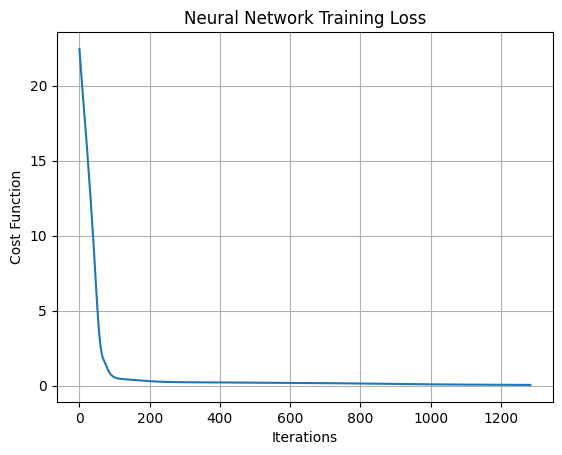

In [26]:
loss_curve = best_model.named_steps["regress"].loss_curve_

plt.figure()
plt.plot(loss_curve)
plt.xlabel("Iterations")
plt.ylabel("Cost Function")
plt.title("Neural Network Training Loss")
plt.grid()
plt.show()

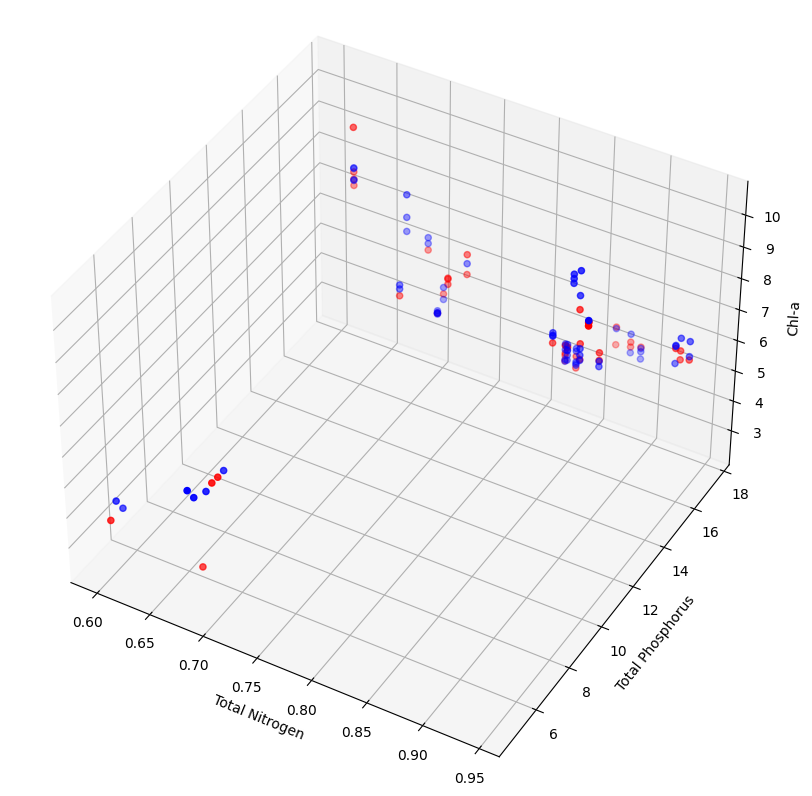

In [27]:
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(projection="3d")

ax.scatter(X_train[:,0], X_train[:,1], y_train, c="blue")
ax.scatter(X_test[:,0], X_test[:,1], y_test, c="red")

ax.set_xlabel("Total Nitrogen")
ax.set_ylabel("Total Phosphorus")
ax.set_zlabel("Chl-a")

ax.view_init(elev=40)

plt.show()

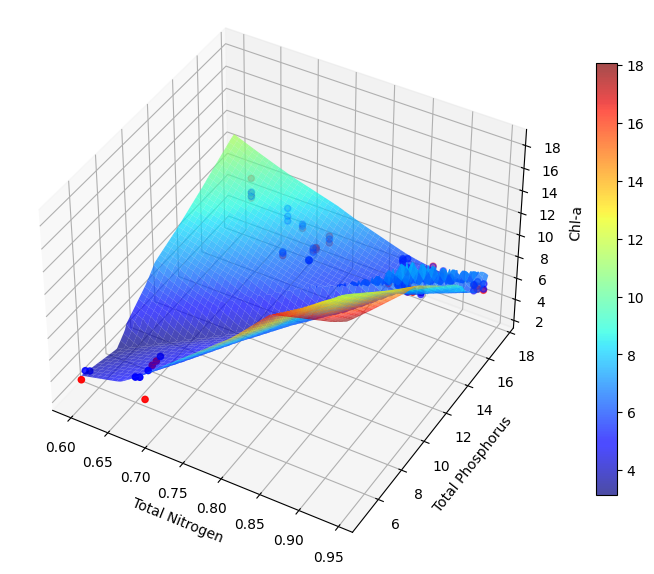

In [28]:
vx, vy = np.meshgrid(np.linspace(X[:,0].min(), X[:,0].max(), 200),np.linspace(X[:,1].min(), X[:,1].max(), 200))
X_grid = np.hstack((vx.reshape(-1,1), vy.reshape(-1,1)))
vz = best_model.predict(X_grid)

fig = plt.figure(figsize=(12,7))
ax = fig.add_subplot(projection="3d")

ax.scatter(X_train[:,0], X_train[:,1], y_train, c="blue")
ax.scatter(X_test[:,0], X_test[:,1], y_test, c="red")

ax.set_xlabel("Total Nitrogen")
ax.set_ylabel("Total Phosphorus")
ax.set_zlabel("Chl-a")

ax.view_init(elev=40)

surf = ax.plot_surface(vx,vy,vz.reshape(vx.shape),
                       linewidth=0,
                       cmap=cm.jet,
                       alpha=0.7
)

fig.colorbar(surf, shrink=0.8)

plt.show()